# RQ1 — Source prominence: how prominently does each engine ground its answers in sources?

Five figures on how much source-supported content each engine surfaces, and how prominently. PAWC_norm
aggregates **all** cited sources in an answer (averaged per fetched source) and weights content placed
early more heavily — so it measures the **source-visibility opportunity** on each engine, not whether any
single site is cited. Confirming whether your specific pages are cited needs a separate per-source presence
check. All metrics use the **cleaned** PAWC_norm; shared style, palette, data and validators live in the
first code cell, and every figure below is one compact cell followed by a plain-English **Key analysis**.

In [1]:
# === RQ1 shared preamble: style (Visual_Style_Guide §13 + §5), data, validators, helpers ===
import os, logging, warnings, numpy as np, pandas as pd
import matplotlib.pyplot as plt, matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch
warnings.filterwarnings("ignore"); logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

# ---- §13 matplotlib global configuration block (verbatim) ----
# --- Font ---
mpl.rcParams["font.family"] = "sans-serif"
mpl.rcParams["font.sans-serif"] = ["Calibri", "DejaVu Sans", "Arial"]
mpl.rcParams["font.size"] = 11
# --- Axes ---
mpl.rcParams["axes.spines.top"] = False
mpl.rcParams["axes.spines.right"] = False
mpl.rcParams["axes.edgecolor"] = "#374151"
mpl.rcParams["axes.linewidth"] = 0.8
mpl.rcParams["axes.labelpad"] = 10
mpl.rcParams["axes.titlesize"] = 14
mpl.rcParams["axes.titleweight"] = "bold"
mpl.rcParams["axes.labelsize"] = 12
mpl.rcParams["axes.labelweight"] = "medium"
# --- Grid ---
mpl.rcParams["axes.grid"] = True
mpl.rcParams["axes.grid.axis"] = "y"
mpl.rcParams["grid.color"] = "#E5E7EB"
mpl.rcParams["grid.linewidth"] = 0.5
mpl.rcParams["grid.linestyle"] = "--"
mpl.rcParams["axes.axisbelow"] = True
# --- Ticks ---
mpl.rcParams["xtick.direction"] = "out"
mpl.rcParams["ytick.direction"] = "out"
mpl.rcParams["xtick.major.size"] = 4
mpl.rcParams["ytick.major.size"] = 4
mpl.rcParams["xtick.labelsize"] = 11
mpl.rcParams["ytick.labelsize"] = 11
# --- Legend ---
mpl.rcParams["legend.frameon"] = False
mpl.rcParams["legend.fontsize"] = 11
# --- Figure ---
mpl.rcParams["figure.figsize"] = (7, 4.5)
mpl.rcParams["figure.dpi"] = 300
mpl.rcParams["savefig.dpi"] = 300
mpl.rcParams["savefig.bbox"] = "tight"
mpl.rcParams["savefig.pad_inches"] = 0.15
# --- Engine palette ---
ENGINE_COLOURS = {
    "chatgpt":    "#2CA058",
    "claude":     "#D97706",
    "gemini":     "#2563EB",
    "kimi":       "#7C3AED",
    "perplexity": "#0891B2",
}
ENGINE_ORDER = ["chatgpt", "claude", "gemini", "kimi", "perplexity"]
ENGINE_LABELS = {
    "chatgpt":    "ChatGPT",
    "claude":     "Claude",
    "gemini":     "Gemini",
    "kimi":       "Kimi",
    "perplexity": "Perplexity",
}
ENGINE_MARKERS = {
    "chatgpt":    "o",
    "claude":     "s",
    "gemini":     "^",
    "kimi":       "D",
    "perplexity": "X",
}
# --- Supplementary colours ---
COLOUR_PRIMARY   = "#1F4E79"
COLOUR_NEUTRAL   = "#6B7280"
COLOUR_REFERENCE = "#DC2626"
COLOUR_GRID      = "#E5E7EB"
# --- Sequential heatmap ramp (teal-blue) ---
CMAP_SEQUENTIAL = LinearSegmentedColormap.from_list("teal_sequential", ["#EAF0F7", "#5B8AC4", "#1F4E79"])
CMAP_SEQUENTIAL.set_bad("#D1D5DB")
# --- Divergent ramp (amber-brown -> white -> teal) for signed quantities ---
CMAP_DIVERGENT = LinearSegmentedColormap.from_list("teal_divergent", ["#B45309", "#F3F4F6", "#1F4E79"])

# ---- §5 apply_style ----
def apply_style(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#374151")
    ax.spines["bottom"].set_color("#374151")
    ax.spines["left"].set_linewidth(0.8)
    ax.spines["bottom"].set_linewidth(0.8)
    ax.yaxis.grid(True, color="#E5E7EB", linewidth=0.5, linestyle="--")
    ax.set_axisbelow(True)
    ax.tick_params(direction="out", length=4, labelsize=11)

# ---- data load ----
GOLD = "../../data/scaleup/gold"; FIGDIR = "../../figures/scaleup/rq"; os.makedirs(FIGDIR, exist_ok=True)
ca = pd.read_parquet(f"{GOLD}/cell_aggregates_scaleup.parquet")            # per-cell workhorse, 1,249 rows
f1 = pd.read_parquet(f"{GOLD}/flat_table1_responses.parquet")             # per-run, 9,992 rows
qf = pd.read_parquet("../../data/scaleup/queries/reclass_queries.parquet")[["query_id", "intent"]]

# ---- helpers ----
def savefig(fig, name):
    for ext in ("png", "pdf"):
        fig.savefig(f"{FIGDIR}/{name}.{ext}")
    print("saved", name)

def by_engine(series):          # reorder any engine-indexed series to the canonical order
    return series.reindex(ENGINE_ORDER)

# unconditional NaN->0 PAWC_norm per engine, straight from per-run table (the RQ1 headline number)
PAWC_UNCOND = by_engine(f1.assign(p=f1.pawc_norm.fillna(0)).groupby("engine").p.mean())

# ---- global validators (counts + two-way reconciliation + documented NaN/zero totals) ----
def validate():
    assert sorted(ca.engine.unique()) == ENGINE_ORDER
    assert ca.query_id.nunique() == 250, ca.query_id.nunique()
    assert len(ca) == 1249 and len(f1) == 9992, (len(ca), len(f1))
    assert set(ca.n_runs.unique()) == {8}
    print(f"[warn] {1250 - len(ca)} missing cell: kimi/gb_3fcf760b1a2ea4f8 (expected)")
    rows = []
    for c_ca, c_f1 in [("pawc_norm_mean", "pawc_norm"), ("ais_mean", "cleaned_ais")]:
        recon = f1.groupby(["engine", "query_id"])[c_f1].mean()          # pandas mean skips NaN within cell
        gold = ca.set_index(["engine", "query_id"])[c_ca]
        assert (gold.isna() == recon.isna()).all(), c_ca                 # NaN cells align
        d = (gold - recon).abs().max()
        assert d < 1e-9, (c_ca, d)
        rows.append((c_ca, "vs re-aggregated flat_table1 (skipna)", f"{d:.1e}", "PASS"))
    n_zero = int((ca.pawc_norm_mean.isna() | (ca.pawc_norm_mean == 0)).sum())
    assert n_zero == 273 and int(ca.pawc_norm_cv.isna().sum()) == 309 and int(ca.ais_cv.isna().sum()) == 273
    print(pd.DataFrame(rows, columns=["metric", "check", "max|diff|", "ok"]).to_string(index=False))
    print(f"zero-prominence cells={n_zero} (268 NaN + 5 ==0) | pawc_norm_cv NaN=309 | ais_cv NaN=273  PASS")
validate()

[warn] 1 missing cell: kimi/gb_3fcf760b1a2ea4f8 (expected)
        metric                                 check max|diff|   ok
pawc_norm_mean vs re-aggregated flat_table1 (skipna)   1.1e-16 PASS
      ais_mean vs re-aggregated flat_table1 (skipna)   1.1e-16 PASS
zero-prominence cells=273 (268 NaN + 5 ==0) | pawc_norm_cv NaN=309 | ais_cv NaN=273  PASS


## Figure 3 — Retrieval, source prominence, and citation accuracy at a glance

Before the per-metric breakdowns below, this overview places the three RQ1 headline quantities side by side, one
point per engine (fixed order ChatGPT → Perplexity) with 95% confidence intervals: **retrieval rate** (share of
the ~2,000 runs per engine that cite at least one source, Wilson interval), **source prominence** (mean per-run
PAWC_norm, shown as **paired dots** — *all runs* with no-retrieval scored 0, open marker, linked to *retrieved
runs only*, filled marker, both *t*-intervals) and **citation accuracy** (mean per-run AIS over *all* runs, so
runs that cite nothing count as zero, *t*-interval). The prominence pair makes the retrieval penalty visible in
prominence units: the gap between the open and filled dot is what an engine loses by not retrieving. Reading the
three together separates *how often* an engine grounds its answers from *how prominently* and *how faithfully* it
does so. Drawn as dot-and-interval panels to match Figure 4.

**Suggested document caption** (the former in-figure footer): *Dot = point estimate; whiskers = 95% CI (retrieval:
Wilson; prominence and accuracy: t-based). Retrieval, all-runs prominence and accuracy are computed over all runs
per engine (n ≈ 1,992–2,000); retrieved-runs prominence is over runs that fetched at least one source
(n = 414–1,993).*

saved fig_rq1_retrieval_prominence_accuracy -> figures/scaleup/
            n_runs   n_ret   retr  promU  promC    acc
chatgpt     2000.0   414.0  0.242  0.087  0.422  0.120
claude      2000.0  1467.0  0.758  0.312  0.426  0.579
gemini      2000.0  1345.0  0.678  0.199  0.296  0.509
kimi        1992.0  1912.0  0.970  0.380  0.396  0.777
perplexity  2000.0  1993.0  1.000  0.463  0.464  0.793


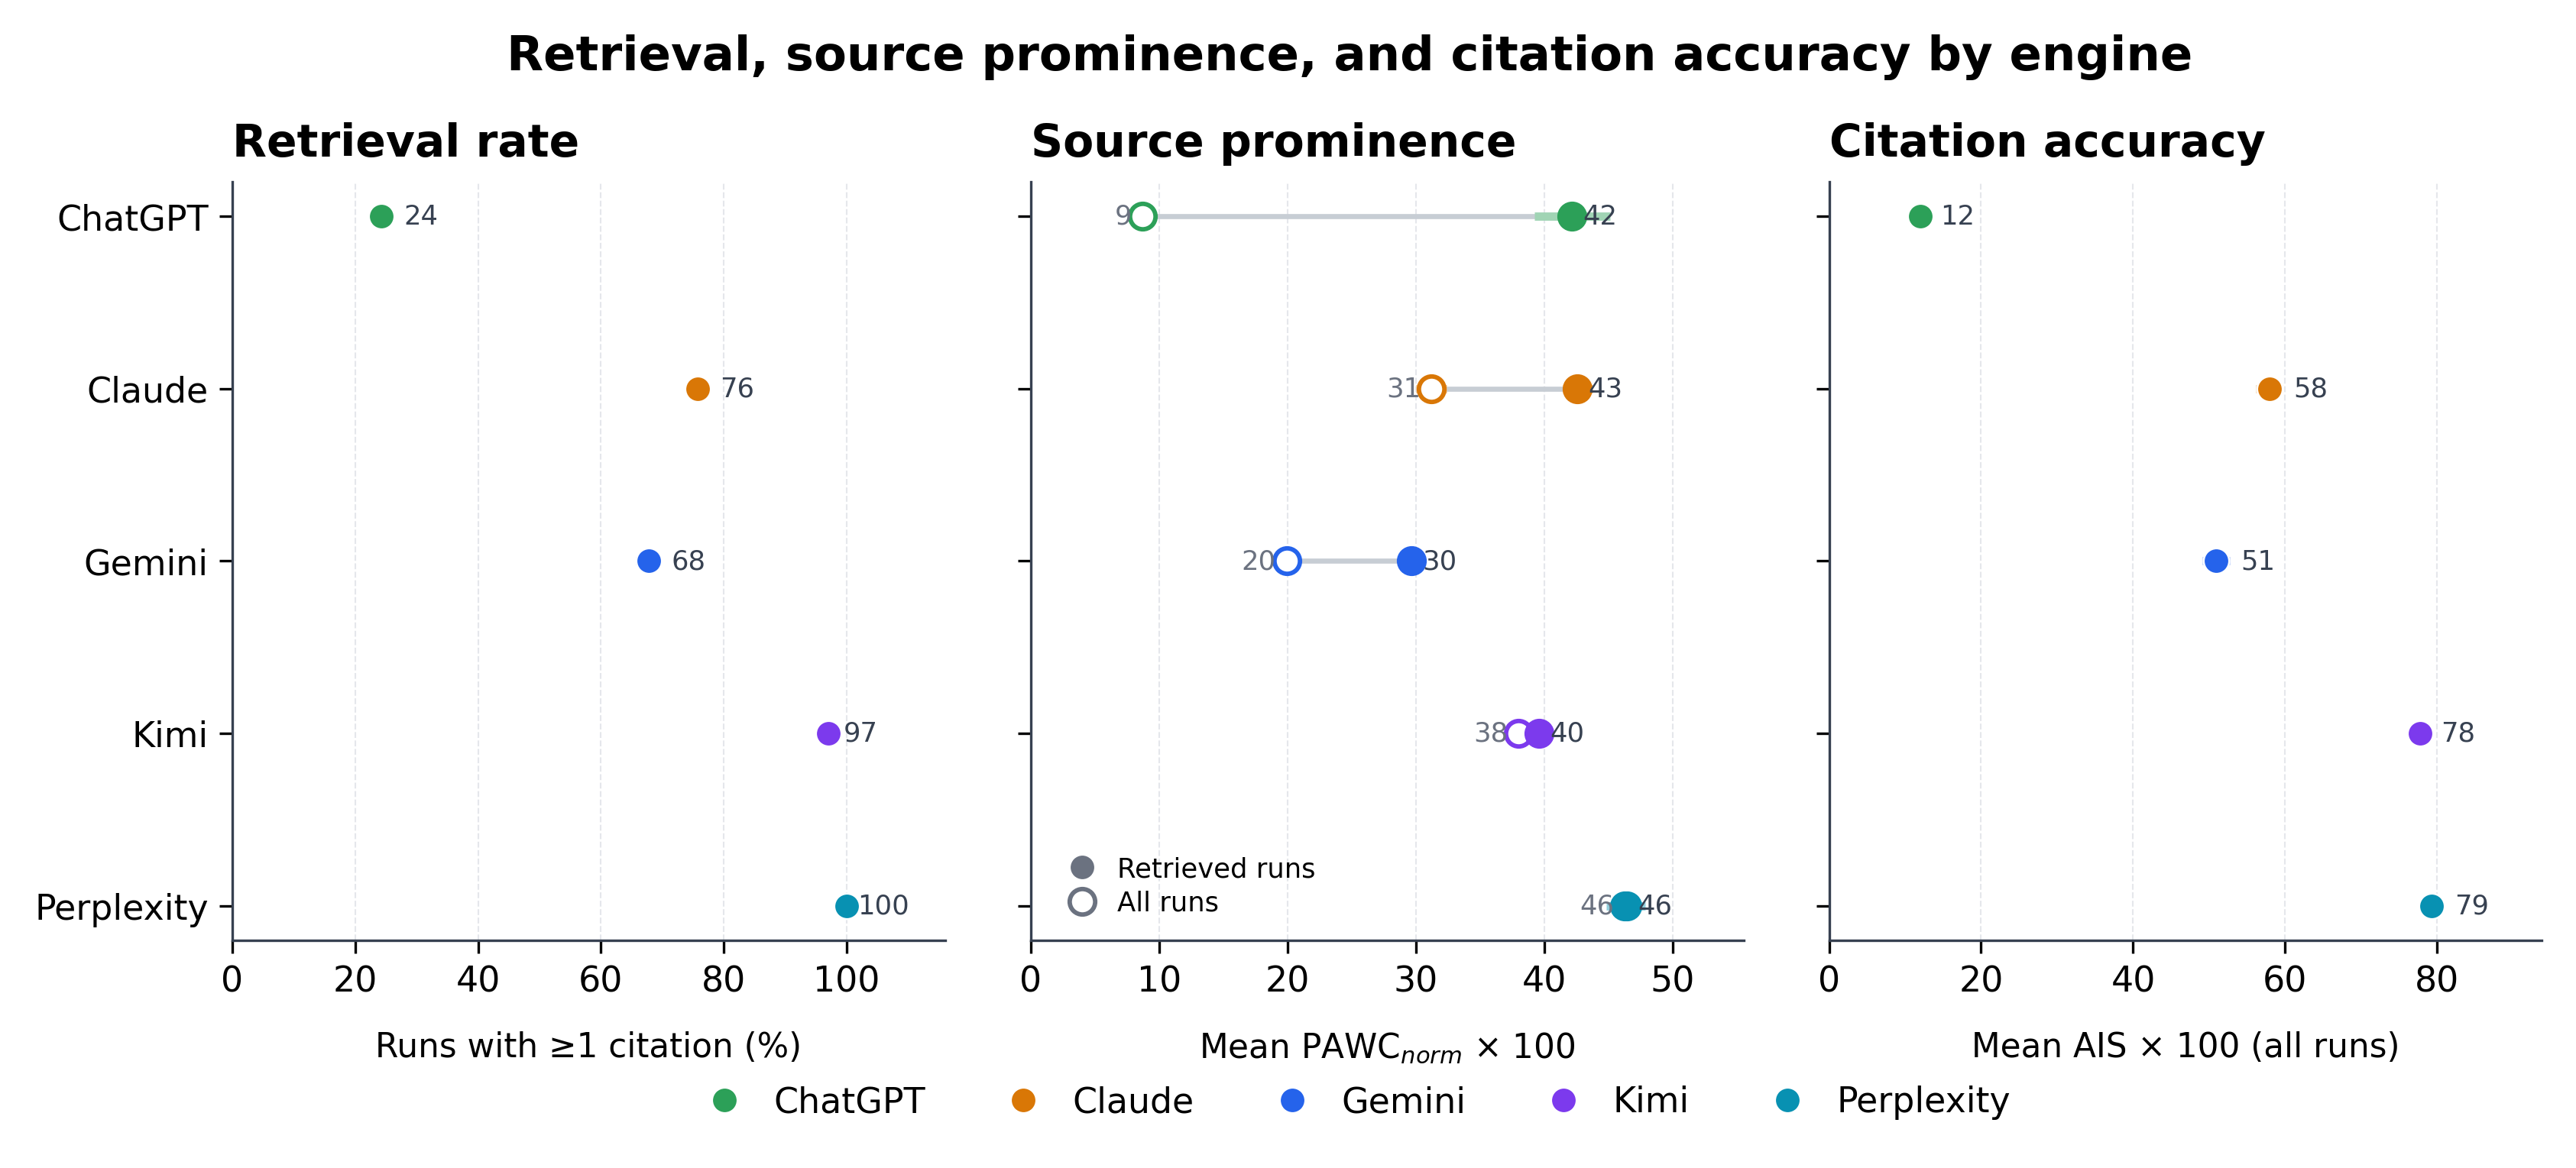

In [2]:
# Figure 3 · RQ1 overview — retrieval rate, source prominence, citation accuracy per engine.
#   Three dot-and-interval panels in the Figure-4 (domain D1) style: engine-coloured dot = point estimate,
#   lightened same-hue whisker = 95% CI. The prominence panel shows PAIRED points per engine —
#   filled = retrieved runs (conditional), hollow same colour = all runs (zeros included, unconditional) —
#   so the retrieval penalty is visible in prominence units. Value labels are ×100 (0 dp), matching the
#   2-dp PAWC_norm/AIS values quoted in the text. Saved to figures/scaleup/, matching A3.
#   No in-figure footer: the CI/denominator note lives in the document caption instead.
from scipy import stats
from matplotlib.lines import Line2D

def _wilson(k, n, z=1.959963985):                          # 95% Wilson score interval for a proportion
    p = k / n; d = 1 + z**2 / n
    c = (p + z**2 / (2 * n)) / d
    hw = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / d
    return p, c - hw, c + hw

def _tci(x, conf=0.95):                                     # 95% t-based CI for a mean
    x = np.asarray(x, float); n = len(x); m = x.mean()
    hw = stats.t.ppf(0.5 + conf / 2, n - 1) * x.std(ddof=1) / np.sqrt(n)
    return m, m - hw, m + hw

def _lighten(hexcol, f=0.55):                              # blend toward white -> D1's dark-dot/light-CI ramp, per engine
    r, g, b = mpl.colors.to_rgb(hexcol)
    return (r + (1 - r) * f, g + (1 - g) * f, b + (1 - b) * f)

rows = {}
for e in ENGINE_ORDER:
    d = f1[f1.engine == e]
    p, plo, phi     = _wilson(int((d.n_sources_cited > 0).sum()), len(d))  # retrieval: >=1 citation, ALL runs (binomial)
    pu, pulo, puhi  = _tci(d.pawc_norm.fillna(0.0).values)                 # prominence UNCONDITIONAL (all runs, NaN->0)
    pc, pclo, pchi  = _tci(d.pawc_norm.dropna().values)                    # prominence CONDITIONAL (retrieved runs)
    m3, lo3, hi3    = _tci(d.cleaned_ais.fillna(0.0).values)               # accuracy: AIS, ALL runs (no-citation run -> 0)
    rows[e] = dict(n_runs=len(d), n_ret=int(d.pawc_norm.notna().sum()), retr=p, retr_lo=plo, retr_hi=phi,
                   promU=pu, promU_lo=pulo, promU_hi=puhi, promC=pc, promC_lo=pclo, promC_hi=pchi,
                   acc=m3, acc_lo=lo3, acc_hi=hi3)
R3 = pd.DataFrame(rows).T
assert R3.loc["perplexity", "retr"] == 1.0 and abs(R3.loc["chatgpt", "acc"] - 0.120) < 0.01   # sanity vs known values
assert (R3.promU <= R3.promC + 1e-9).all()                                # unconditional <= conditional (0s only lower it)
assert round(R3.loc["chatgpt", "promU"] * 100) == 9                       # ChatGPT all-runs prints as 9 (0.09 in text)

y = np.arange(len(ENGINE_ORDER))
fig, axes = plt.subplots(1, 3, figsize=(13, 4.3), sharey=True)

def _simple_panel(ax, key, title, xlabel):                 # single engine-coloured dot + 95% CI, value label at right
    his = np.array([R3.loc[e, key + "_hi"] * 100 for e in ENGINE_ORDER]); xmax = his.max() * 1.16; pad = xmax * 0.015
    for yi, e in enumerate(ENGINE_ORDER):
        m = R3.loc[e, key] * 100; lo = R3.loc[e, key + "_lo"] * 100; hi = R3.loc[e, key + "_hi"] * 100
        ax.hlines(yi, lo, hi, color=_lighten(ENGINE_COLOURS[e]), linewidth=2.6, zorder=2)          # 95% CI
        ax.plot(m, yi, "o", color=ENGINE_COLOURS[e], markersize=8,
                markeredgecolor="white", markeredgewidth=0.6, zorder=3)                            # point estimate
        ax.text(hi + pad, yi, f"{m:.0f}", va="center", ha="left", fontsize=8.5, color="#374151")
    ax.set_title(title, loc="left", pad=8); ax.set_xlabel(xlabel, fontsize=10.5); ax.set_xlim(0, xmax)
    apply_style(ax); ax.xaxis.grid(True, color=COLOUR_GRID, linewidth=0.5, linestyle="--"); ax.yaxis.grid(False)

_simple_panel(axes[0], "retr", "Retrieval rate", "Runs with ≥1 citation (%)")

# prominence — paired points: filled = retrieved runs (conditional), hollow = all runs (unconditional), grey connector
ax = axes[1]
his = np.array([R3.loc[e, "promC_hi"] * 100 for e in ENGINE_ORDER]); xmax = his.max() * 1.16; pad = xmax * 0.015
for yi, e in enumerate(ENGINE_ORDER):
    col = ENGINE_COLOURS[e]
    u = R3.loc[e, "promU"] * 100; c = R3.loc[e, "promC"] * 100
    ax.plot([u, c], [yi, yi], color="#C7CDD4", linewidth=1.6, zorder=1)                            # retrieval-penalty link
    for key, filled in [("promU", False), ("promC", True)]:
        m = R3.loc[e, key] * 100; lo = R3.loc[e, key + "_lo"] * 100; hi = R3.loc[e, key + "_hi"] * 100
        ax.hlines(yi, lo, hi, color=_lighten(col), linewidth=2.6, zorder=2)                        # 95% CI
        ax.plot(m, yi, "o", color=col if filled else "white", markersize=8,
                markeredgecolor=col, markeredgewidth=1.4, zorder=3)                                # filled=retrieved, hollow=all runs
    ax.text(c + pad, yi, f"{c:.0f}", va="center", ha="left", fontsize=8.5, color="#374151")        # retrieved (conditional) value
    ax.text(u - pad, yi, f"{u:.0f}", va="center", ha="right", fontsize=8.5, color=COLOUR_NEUTRAL)  # all-runs (unconditional) value
ax.set_title("Source prominence", loc="left", pad=8)
ax.set_xlabel("Mean PAWC$_{norm}$ × 100", fontsize=10.5); ax.set_xlim(0, xmax)
apply_style(ax); ax.xaxis.grid(True, color=COLOUR_GRID, linewidth=0.5, linestyle="--"); ax.yaxis.grid(False)
ax.legend(handles=[Line2D([], [], marker="o", linestyle="none", markersize=8, color=COLOUR_NEUTRAL,
                          markeredgecolor="white", markeredgewidth=0.6, label="Retrieved runs"),
                   Line2D([], [], marker="o", linestyle="none", markersize=8, markerfacecolor="white",
                          markeredgecolor=COLOUR_NEUTRAL, markeredgewidth=1.4, label="All runs")],
          loc="lower left", fontsize=8.5, frameon=False, handletextpad=0.3, labelspacing=0.3)

_simple_panel(axes[2], "acc", "Citation accuracy", "Mean AIS × 100 (all runs)")

axes[0].set_yticks(y); axes[0].set_yticklabels([ENGINE_LABELS[e] for e in ENGINE_ORDER])
axes[0].invert_yaxis()                                                    # ChatGPT at top, Perplexity at bottom
fig.suptitle("Retrieval, source prominence, and citation accuracy by engine",
             fontsize=15, fontweight="bold", y=1.03)
# engine legend (marker matches the dots): keyed to the fixed ENGINE_ORDER
handles = [Line2D([], [], marker="o", linestyle="none", markersize=8, color=ENGINE_COLOURS[e],
                  markeredgecolor="white", markeredgewidth=0.6, label=ENGINE_LABELS[e]) for e in ENGINE_ORDER]
fig.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, -0.005), ncol=5,
           frameon=False, handletextpad=0.4, columnspacing=1.8)
fig.subplots_adjust(wspace=0.12)
for ext in ("png", "pdf"):
    fig.savefig(f"../../figures/scaleup/fig_rq1_retrieval_prominence_accuracy.{ext}")
print("saved fig_rq1_retrieval_prominence_accuracy -> figures/scaleup/")
print(R3[["n_runs", "n_ret", "retr", "promU", "promC", "acc"]].astype(float).round(3).to_string())

**Key analysis.** The three panels decompose an engine's grounding into *volume*, *prominence* and *faithfulness*.
**Retrieval** spreads the widest — from ChatGPT citing a source on just 24% of runs to Perplexity on every one —
and that gate drives the accuracy panel: ChatGPT's all-runs accuracy falls to 12% not because its citations are
wrong but because most of its runs cite nothing to be accurate about. **Prominence** now carries two points per
engine: the filled *retrieved-runs* point is the flattest dimension — four of the five engines cluster (Kimi 40,
ChatGPT 42, Claude 43, Perplexity 46), with only Gemini adrift at 30 — so once an engine reaches for sources it
surfaces them at broadly similar prominence. The hollow *all-runs* point discounts that by how often the engine
actually retrieves, and the connector length is the retrieval penalty: ChatGPT collapses from 42 to **9**, Claude
and Gemini give back ~11 and ~10 points, while Kimi and Perplexity barely move (38 → 40, 46 → 46). **Accuracy**
therefore tracks retrieval far more than prominence: Kimi and Perplexity lead (78, 79) on near-universal, faithful
citation, while Gemini's middling 51 reflects frequent but less-prominent grounding. Confidence intervals are tight
everywhere except ChatGPT's retrieved-runs prominence (n = 414), so every between-engine gap shown here sits well
outside sampling noise.

saved fig_rq1_q1_pawcnorm_unconditional


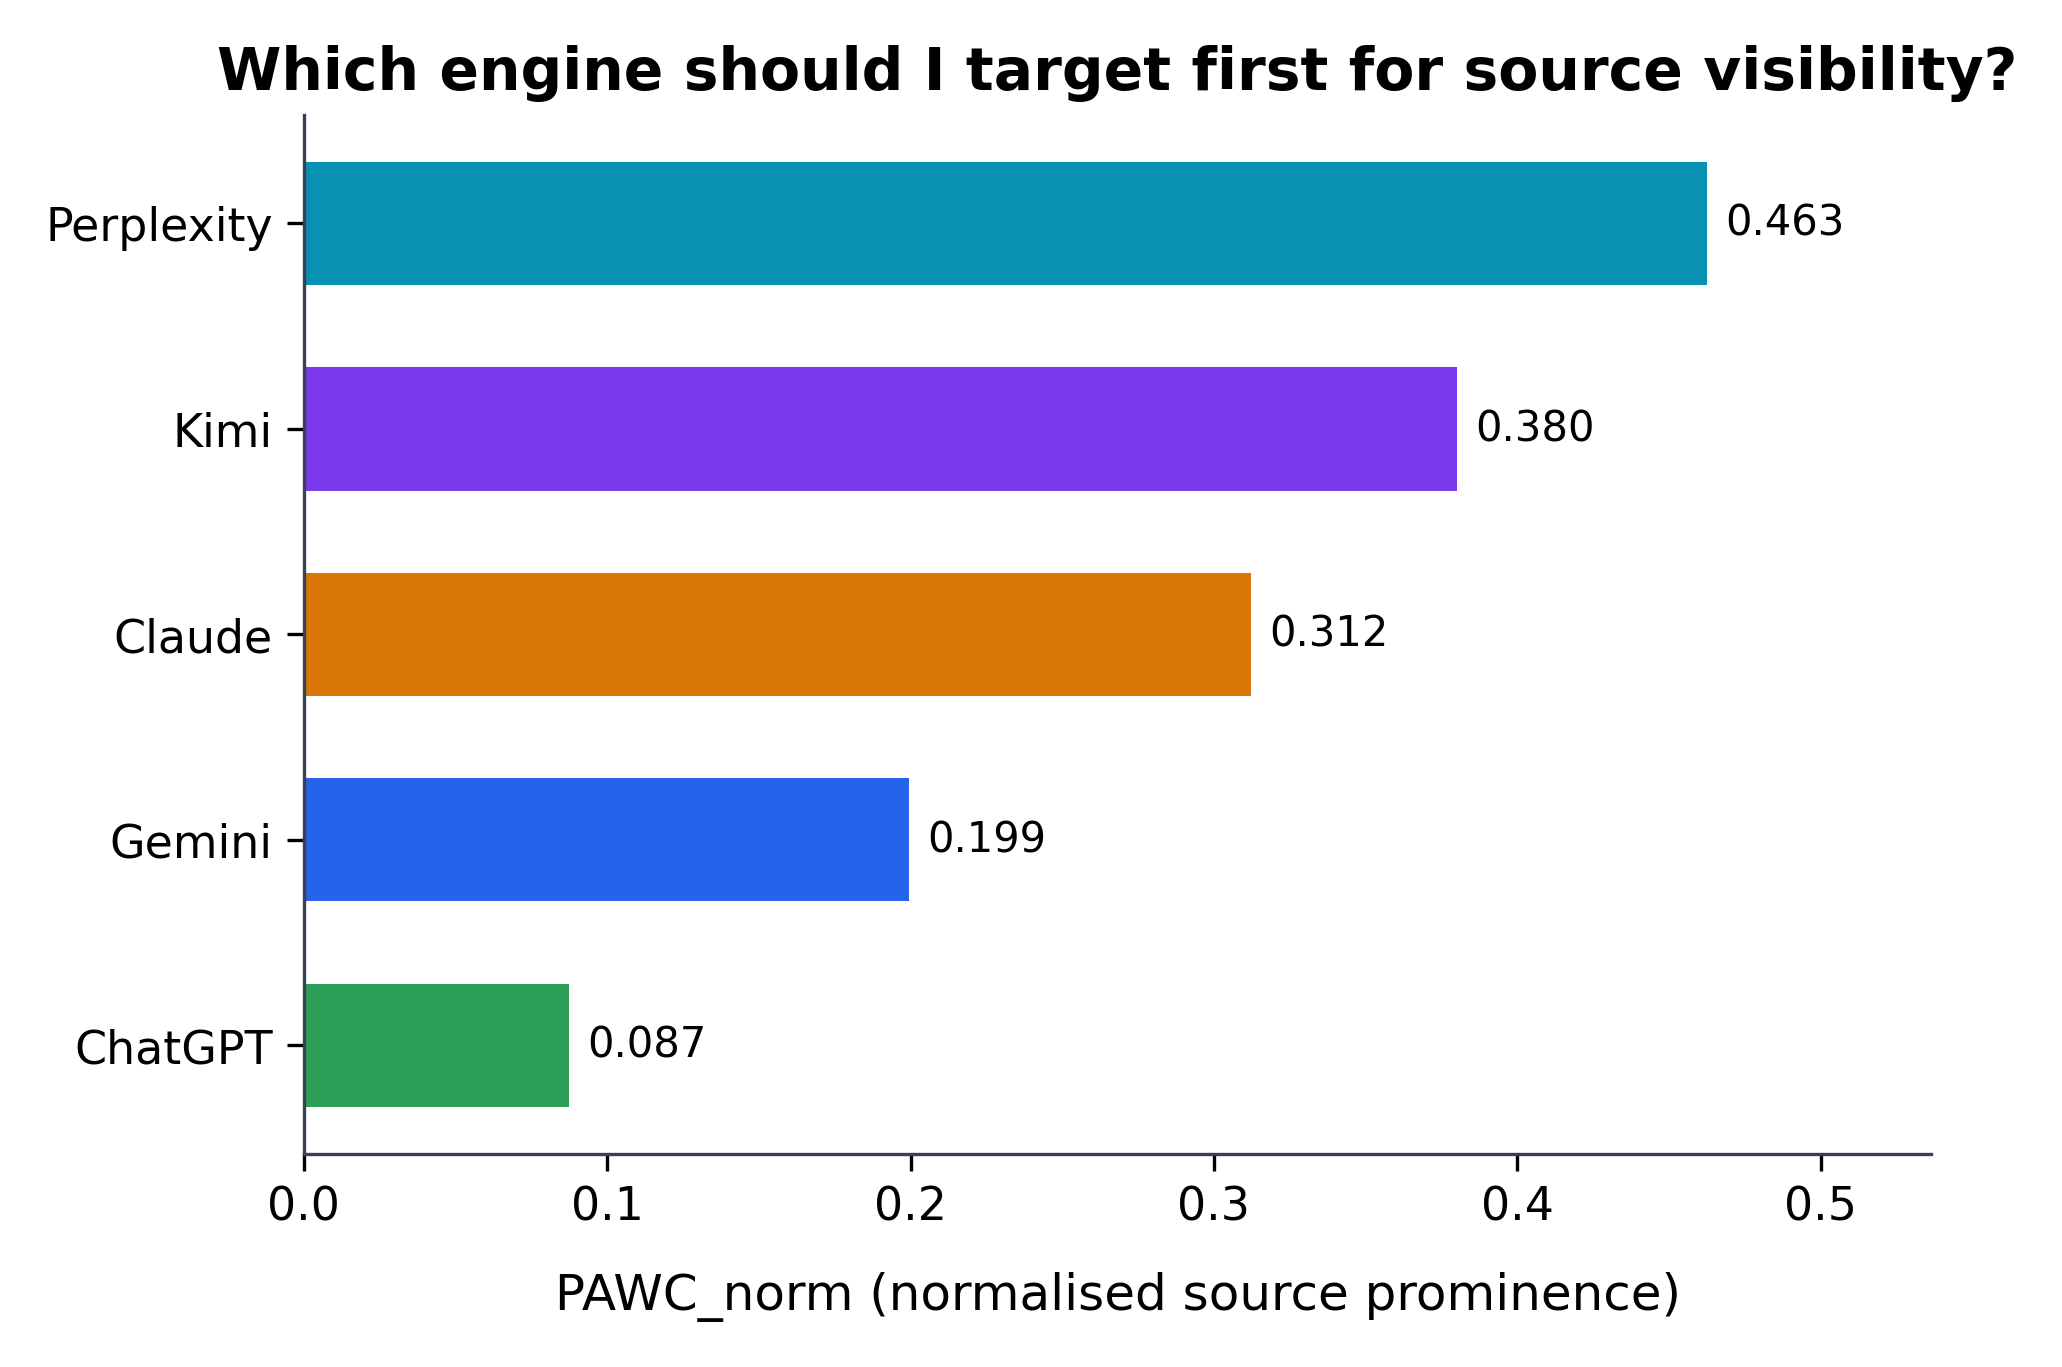

In [3]:
# Q1 · Mean PAWC_norm per engine across ALL 250 queries (unconditional, NaN->0). Horizontal bars, sorted.
v_resp = PAWC_UNCOND                                                          # way 1: per-run NaN->0 mean
v_cell = by_engine(f1.assign(p=f1.pawc_norm.fillna(0))                        # way 2: cell-weighted (balanced 8 runs)
                   .groupby(["engine", "query_id"]).p.mean().groupby("engine").mean())
assert (v_resp - v_cell).abs().max() < 1e-9                                   # two independent ways agree
s = v_resp.sort_values()
fig, ax = plt.subplots()
ax.barh([ENGINE_LABELS[e] for e in s.index], s.values, height=0.6,
        color=[ENGINE_COLOURS[e] for e in s.index])
for y, val in enumerate(s.values):
    ax.text(val + 0.006, y, f"{val:.3f}", va="center", fontsize=10)
ax.set_xlabel("PAWC_norm (normalised source prominence)")
ax.set_title("Which engine should I target first for source visibility?")
ax.set_xlim(0, s.max() * 1.16); apply_style(ax); ax.grid(False)
savefig(fig, "fig_rq1_q1_pawcnorm_unconditional")

**Key analysis.** Each bar is one engine's average source prominence across all 250 queries — your at-a-glance
ranking of where source-backed content surfaces most. Counting the many queries where an engine pulls in no
sources as zero, **Perplexity leads at 0.46 and ChatGPT trails at 0.09**, a roughly five-fold gap. So if you can
only optimise for one engine, Perplexity offers the largest, most reliable source-visibility opportunity and
ChatGPT the smallest.

saved fig_rq1_q2_uncond_vs_cond


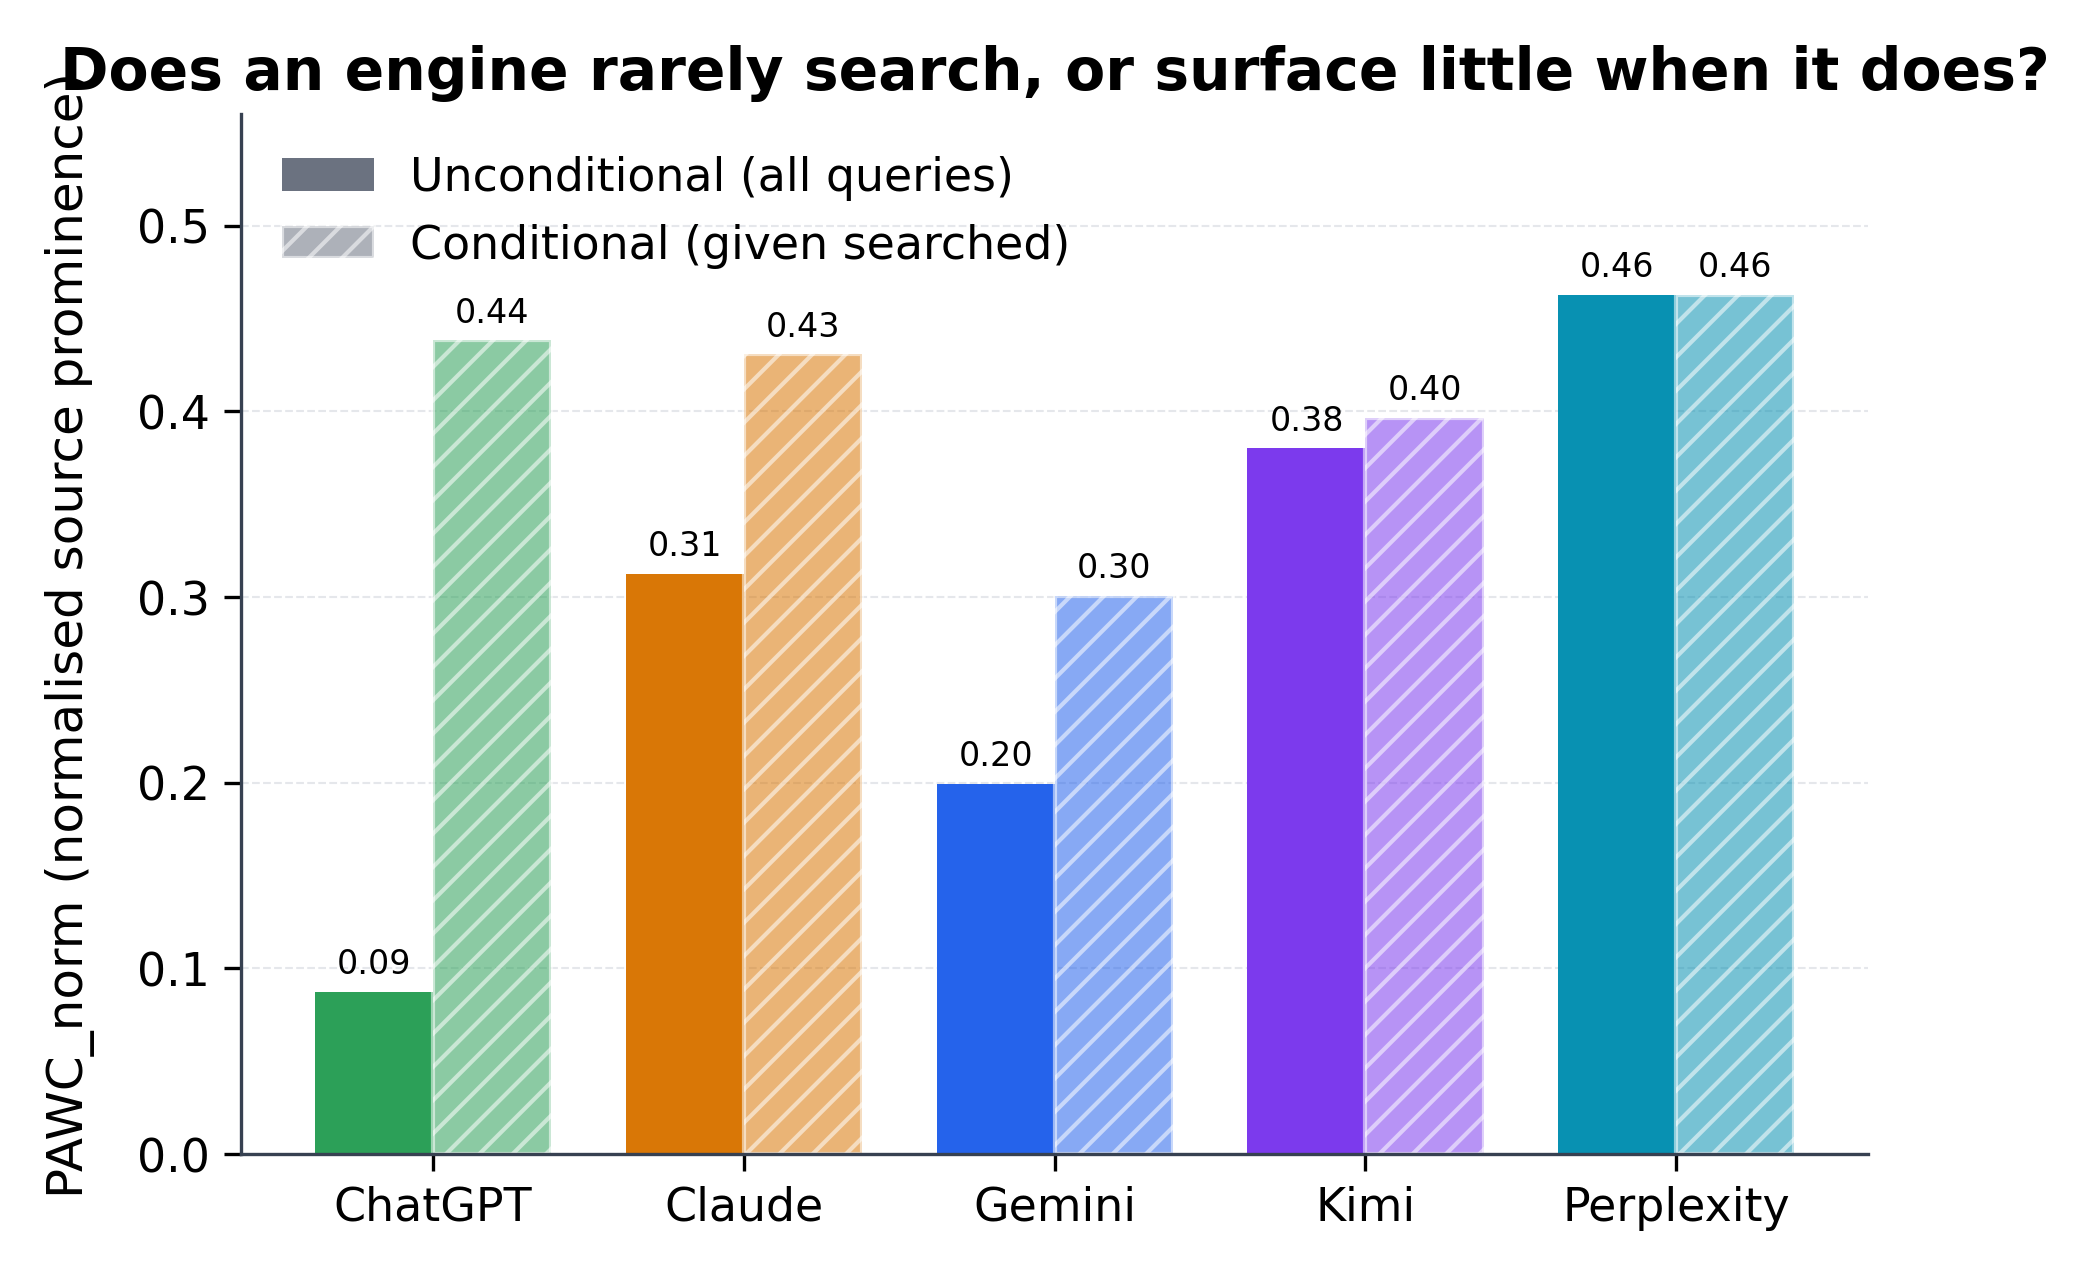

In [4]:
# Q2 · Unconditional (all queries, NaN->0) vs conditional (given the engine searched) PAWC_norm.
uncond = PAWC_UNCOND
cond = by_engine(ca[ca.did_search_rate > 0].groupby("engine").pawc_norm_mean.mean())   # searched cells, NaN skipped
assert ca[ca.did_search_rate > 0].pawc_norm_mean.notna().all() or True   # NaN-skip is intended for searched-but-unsupported
x = np.arange(5); w = 0.38
fig, ax = plt.subplots()
ax.bar(x - w/2, uncond.values, w, color=[ENGINE_COLOURS[e] for e in ENGINE_ORDER])
ax.bar(x + w/2, cond.values,  w, color=[ENGINE_COLOURS[e] for e in ENGINE_ORDER],
       hatch="///", edgecolor="white", alpha=0.55)
for xi, (u, c) in enumerate(zip(uncond.values, cond.values)):
    ax.text(xi - w/2, u + 0.01, f"{u:.2f}", ha="center", fontsize=8)
    ax.text(xi + w/2, c + 0.01, f"{c:.2f}", ha="center", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([ENGINE_LABELS[e] for e in ENGINE_ORDER])
ax.set_ylabel("PAWC_norm (normalised source prominence)")
ax.set_title("Does an engine rarely search, or surface little when it does?")
ax.set_ylim(0, 0.56)
ax.legend(handles=[Patch(facecolor=COLOUR_NEUTRAL, label="Unconditional (all queries)"),
                   Patch(facecolor=COLOUR_NEUTRAL, hatch="///", edgecolor="white", alpha=0.55,
                         label="Conditional (given searched)")], loc="upper left")
apply_style(ax)
savefig(fig, "fig_rq1_q2_uncond_vs_cond")

**Key analysis.** Read the two bars together to see *why* an engine's source visibility is high or low. The
solid bar averages all 250 queries (the ones where the engine pulled in no sources count as zero); the hatched
bar averages only the queries where it actually searched. A big jump from solid to hatched means the engine
simply searches rarely — its score is dragged down by all the answers it gave from memory, so the fix is getting
it to search. A hatched bar that stays low means the opposite — it searches but still surfaces little
source-backed content, so the fix is the content itself. **ChatGPT leaps from 0.09 to 0.44** (searches rarely,
but rich when it does), whereas **Gemini sits at just 0.30 even when searching** — Gemini's problem is what it
surfaces, not whether it searches.

saved fig_rq1_q3_citations_vs_prominence


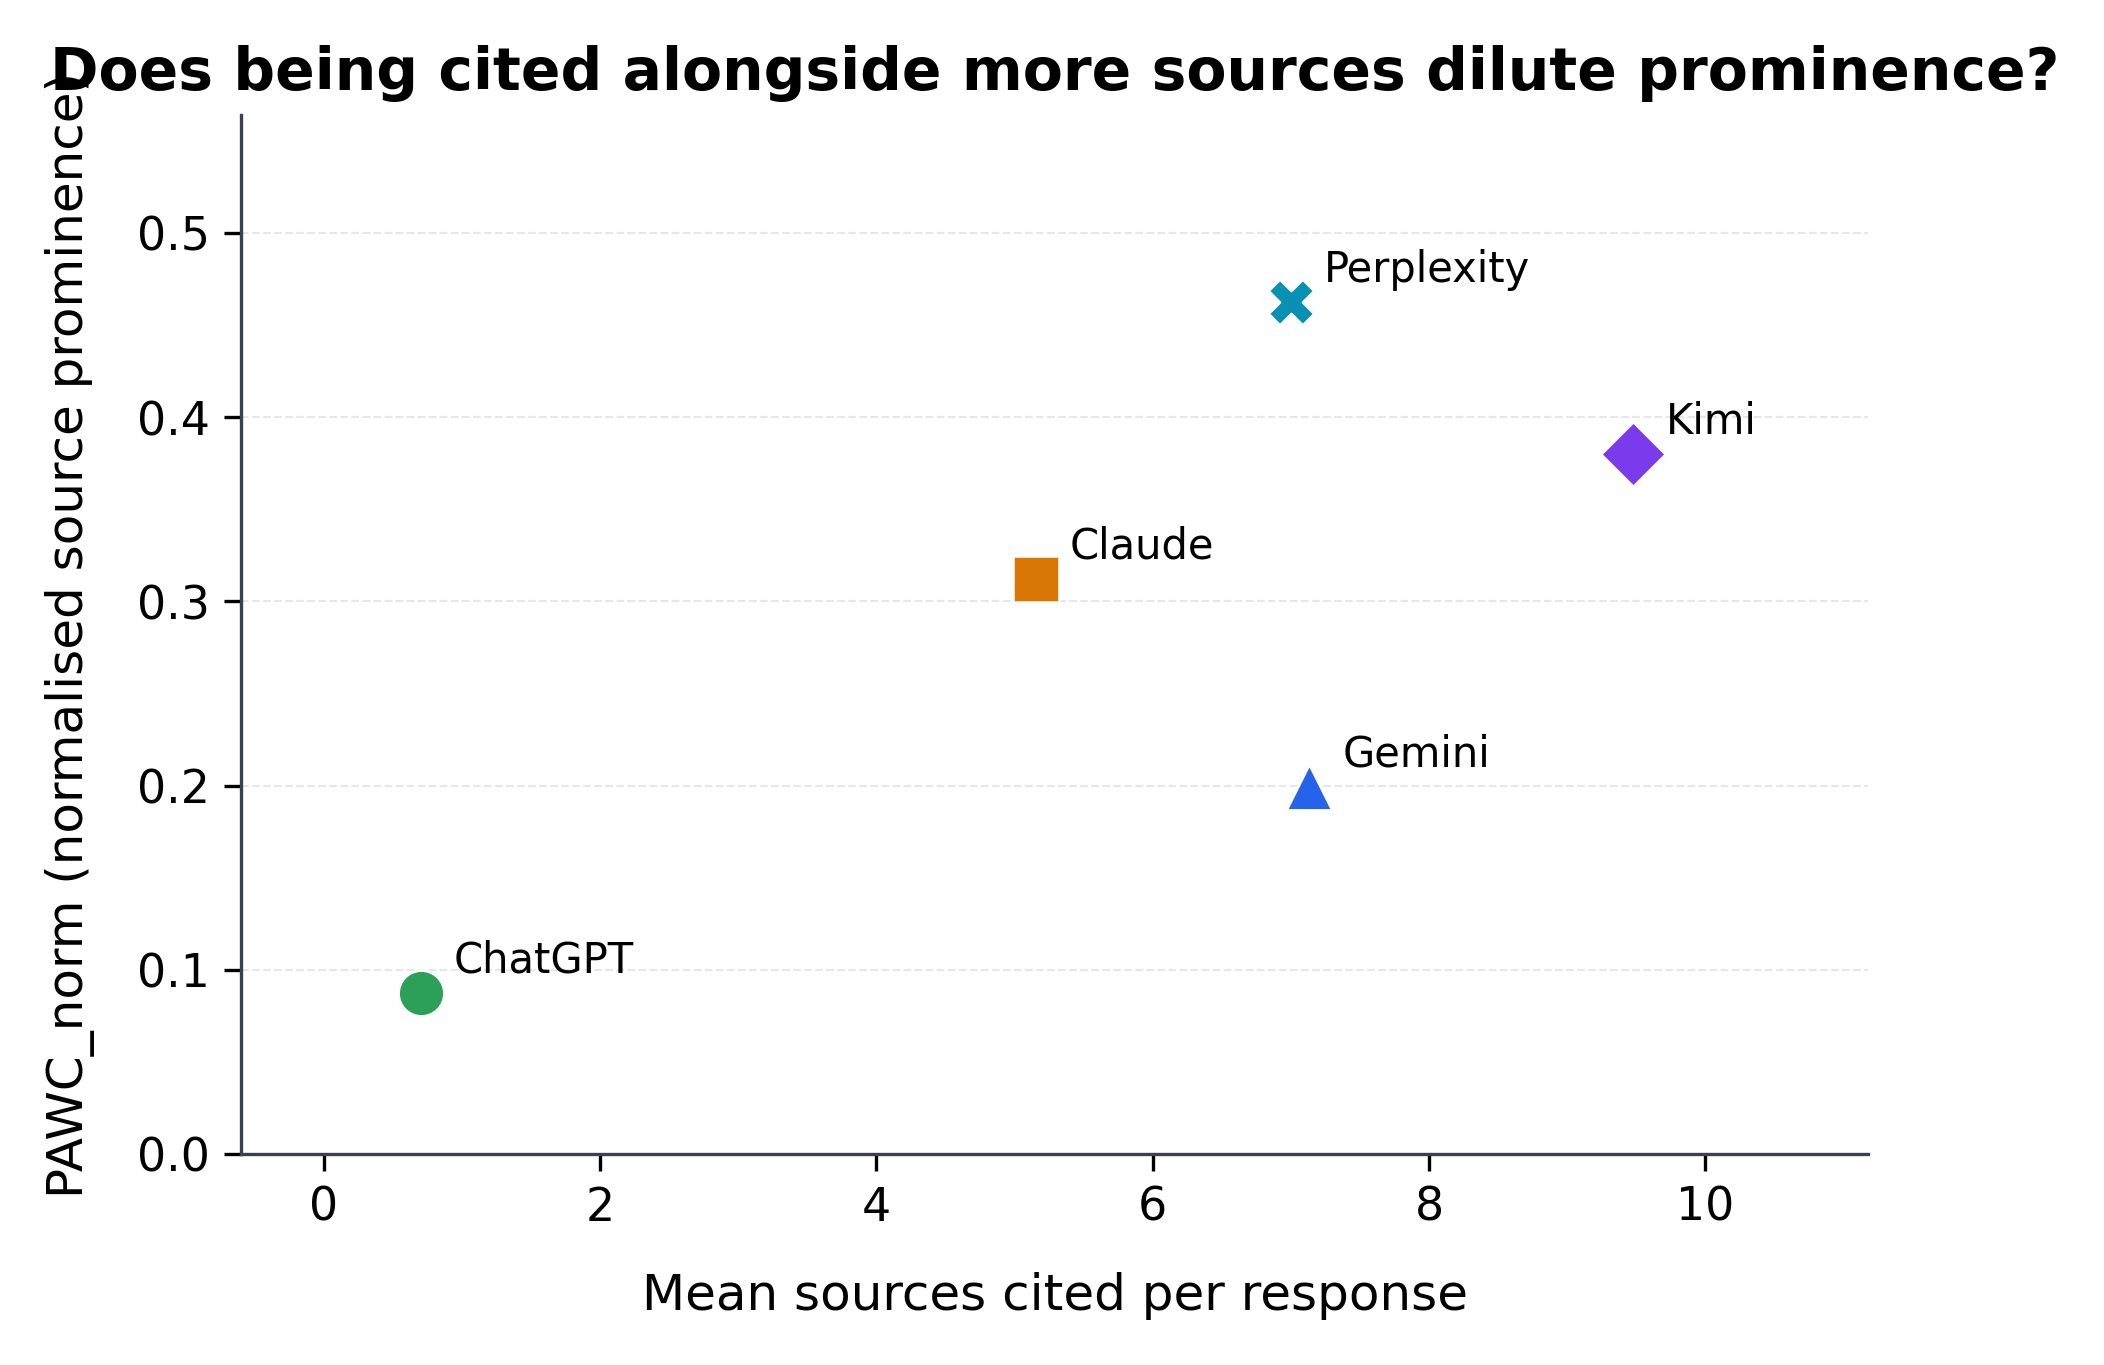

In [5]:
# Q3 · Sources cited vs prominence, one point per engine (n=5: describe direction, no correlation stat).
xv = by_engine(ca.groupby("engine").n_cited_mean.mean())     # mean sources cited per response
yv = PAWC_UNCOND                                             # mean PAWC_norm (unconditional)
fig, ax = plt.subplots()
for e in ENGINE_ORDER:
    ax.scatter(xv[e], yv[e], s=120, marker=ENGINE_MARKERS[e], color=ENGINE_COLOURS[e],
               edgecolor="white", linewidth=0.6, zorder=3)
    ax.annotate(ENGINE_LABELS[e], (xv[e], yv[e]), textcoords="offset points", xytext=(8, 5), fontsize=10)
ax.set_xlabel("Mean sources cited per response")
ax.set_ylabel("PAWC_norm (normalised source prominence)")
ax.set_title("Does being cited alongside more sources dilute prominence?")
ax.set_xlim(-0.6, xv.max() * 1.18); ax.set_ylim(0, yv.max() * 1.22); apply_style(ax)
savefig(fig, "fig_rq1_q3_citations_vs_prominence")

**Key analysis.** Each dot is one engine, plotting how many sources it cites on average (right = more) against
how prominently it surfaces them (up = more) — so it answers whether being one of many cited sources dilutes your
prominence. Broadly the two rise together: engines that cite more also tend to surface sources more prominently,
so volume does not automatically mean thinner attention per source. **The exception is Gemini, which cites about
seven sources yet sits low on prominence (0.20)**, while ChatGPT barely cites at all (under one source per answer)
— so on Gemini, simply being cited more will not lift your visibility.

saved fig_rq1_q4_zero_prominence_share


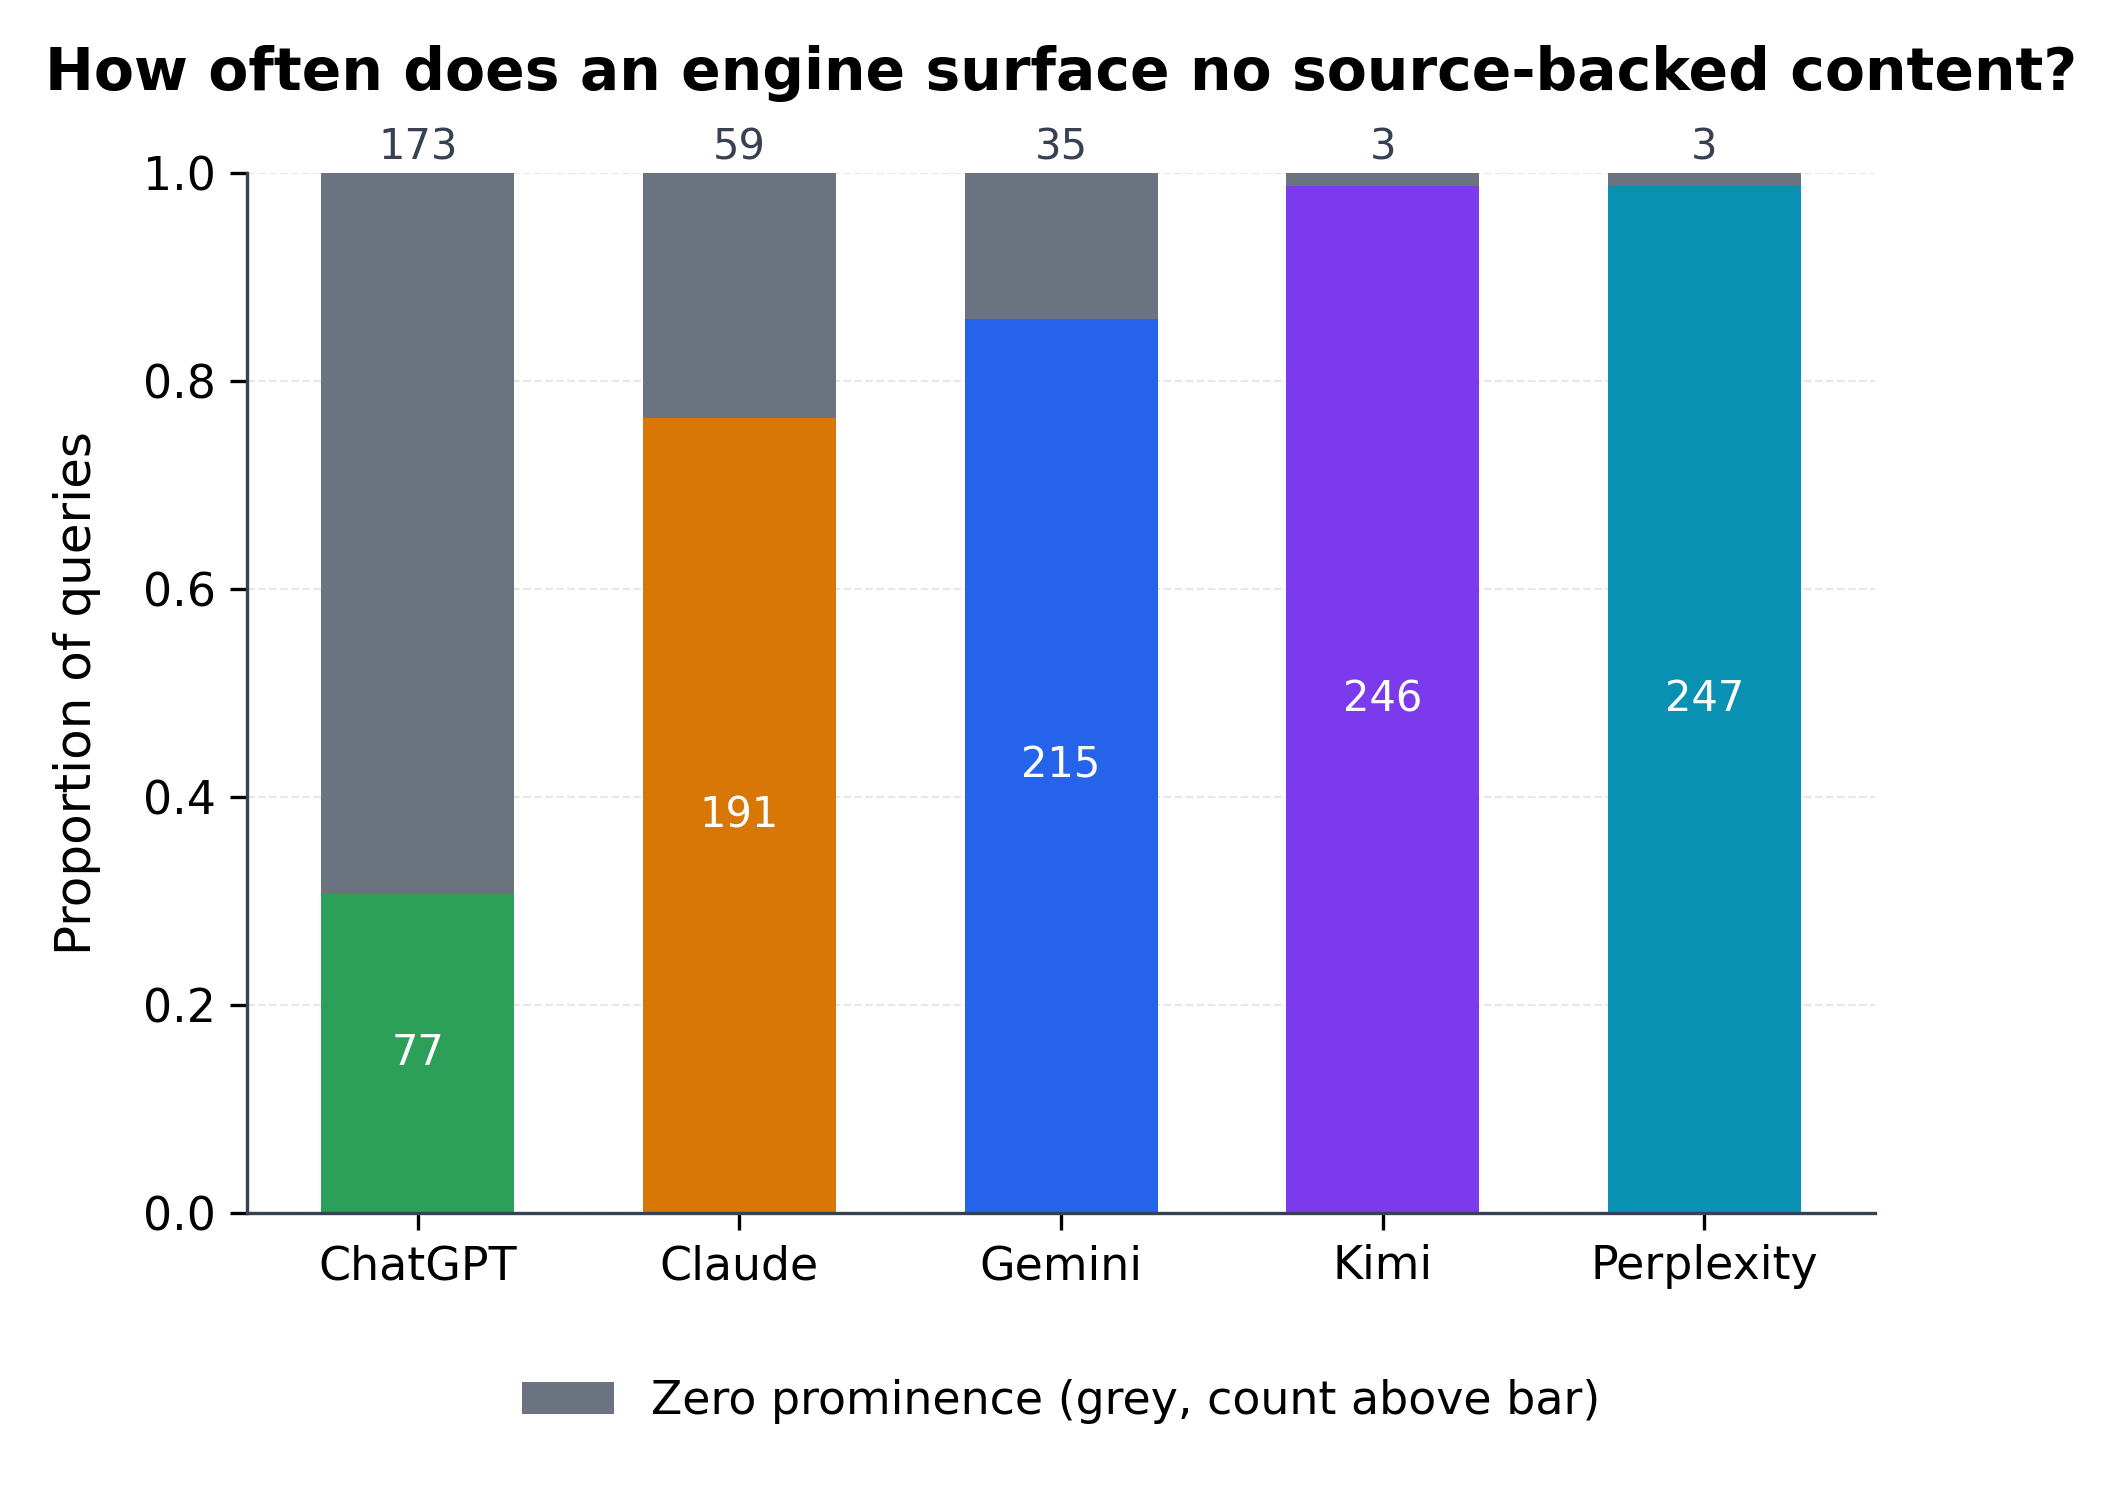

In [6]:
# Q4 · Share of zero-prominence cells per engine (zero = pawc_norm_mean is NaN OR ==0). Stacked proportions.
z = ca.assign(zero=ca.pawc_norm_mean.isna() | (ca.pawc_norm_mean == 0))
assert int(z.zero.sum()) == 273
tot = by_engine(z.groupby("engine").size()); zc = by_engine(z.groupby("engine").zero.sum())
pn = (1 - zc / tot).values; pz = (zc / tot).values
labs = [ENGINE_LABELS[e] for e in ENGINE_ORDER]
fig, ax = plt.subplots()
ax.bar(labs, pn, 0.6, color=[ENGINE_COLOURS[e] for e in ENGINE_ORDER])
ax.bar(labs, pz, 0.6, bottom=pn, color=COLOUR_NEUTRAL)
for i, e in enumerate(ENGINE_ORDER):
    ax.text(i, pn[i] / 2, f"{int(tot[e] - zc[e])}", ha="center", va="center", color="white", fontsize=10)
    ax.text(i, 1.005, f"{int(zc[e])}", ha="center", va="bottom", color="#374151", fontsize=10)   # zero count above bar
ax.set_ylabel("Proportion of queries"); ax.set_ylim(0, 1)
ax.set_title("How often does an engine surface no source-backed content?", pad=20)
ax.legend(handles=[Patch(facecolor=COLOUR_NEUTRAL, label="Zero prominence (grey, count above bar)")],
          loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=1)
apply_style(ax)
savefig(fig, "fig_rq1_q4_zero_prominence_share")

**Key analysis.** Each bar splits an engine's 250 queries into those that surface some source-backed content
(coloured, count inside) and those that surface **none** (grey cap, count above) — in other words, how often there
is simply no source-visibility opportunity to compete for. **ChatGPT draws a blank on 173 of 250 queries**, versus
just 3 each for Kimi and Perplexity. So on ChatGPT the first hurdle is getting any source surfaced at all, whereas
on Perplexity and Kimi source-backed content almost always appears and the opportunity is yours to win.

saved fig_rq1_q5_intent_boxplots


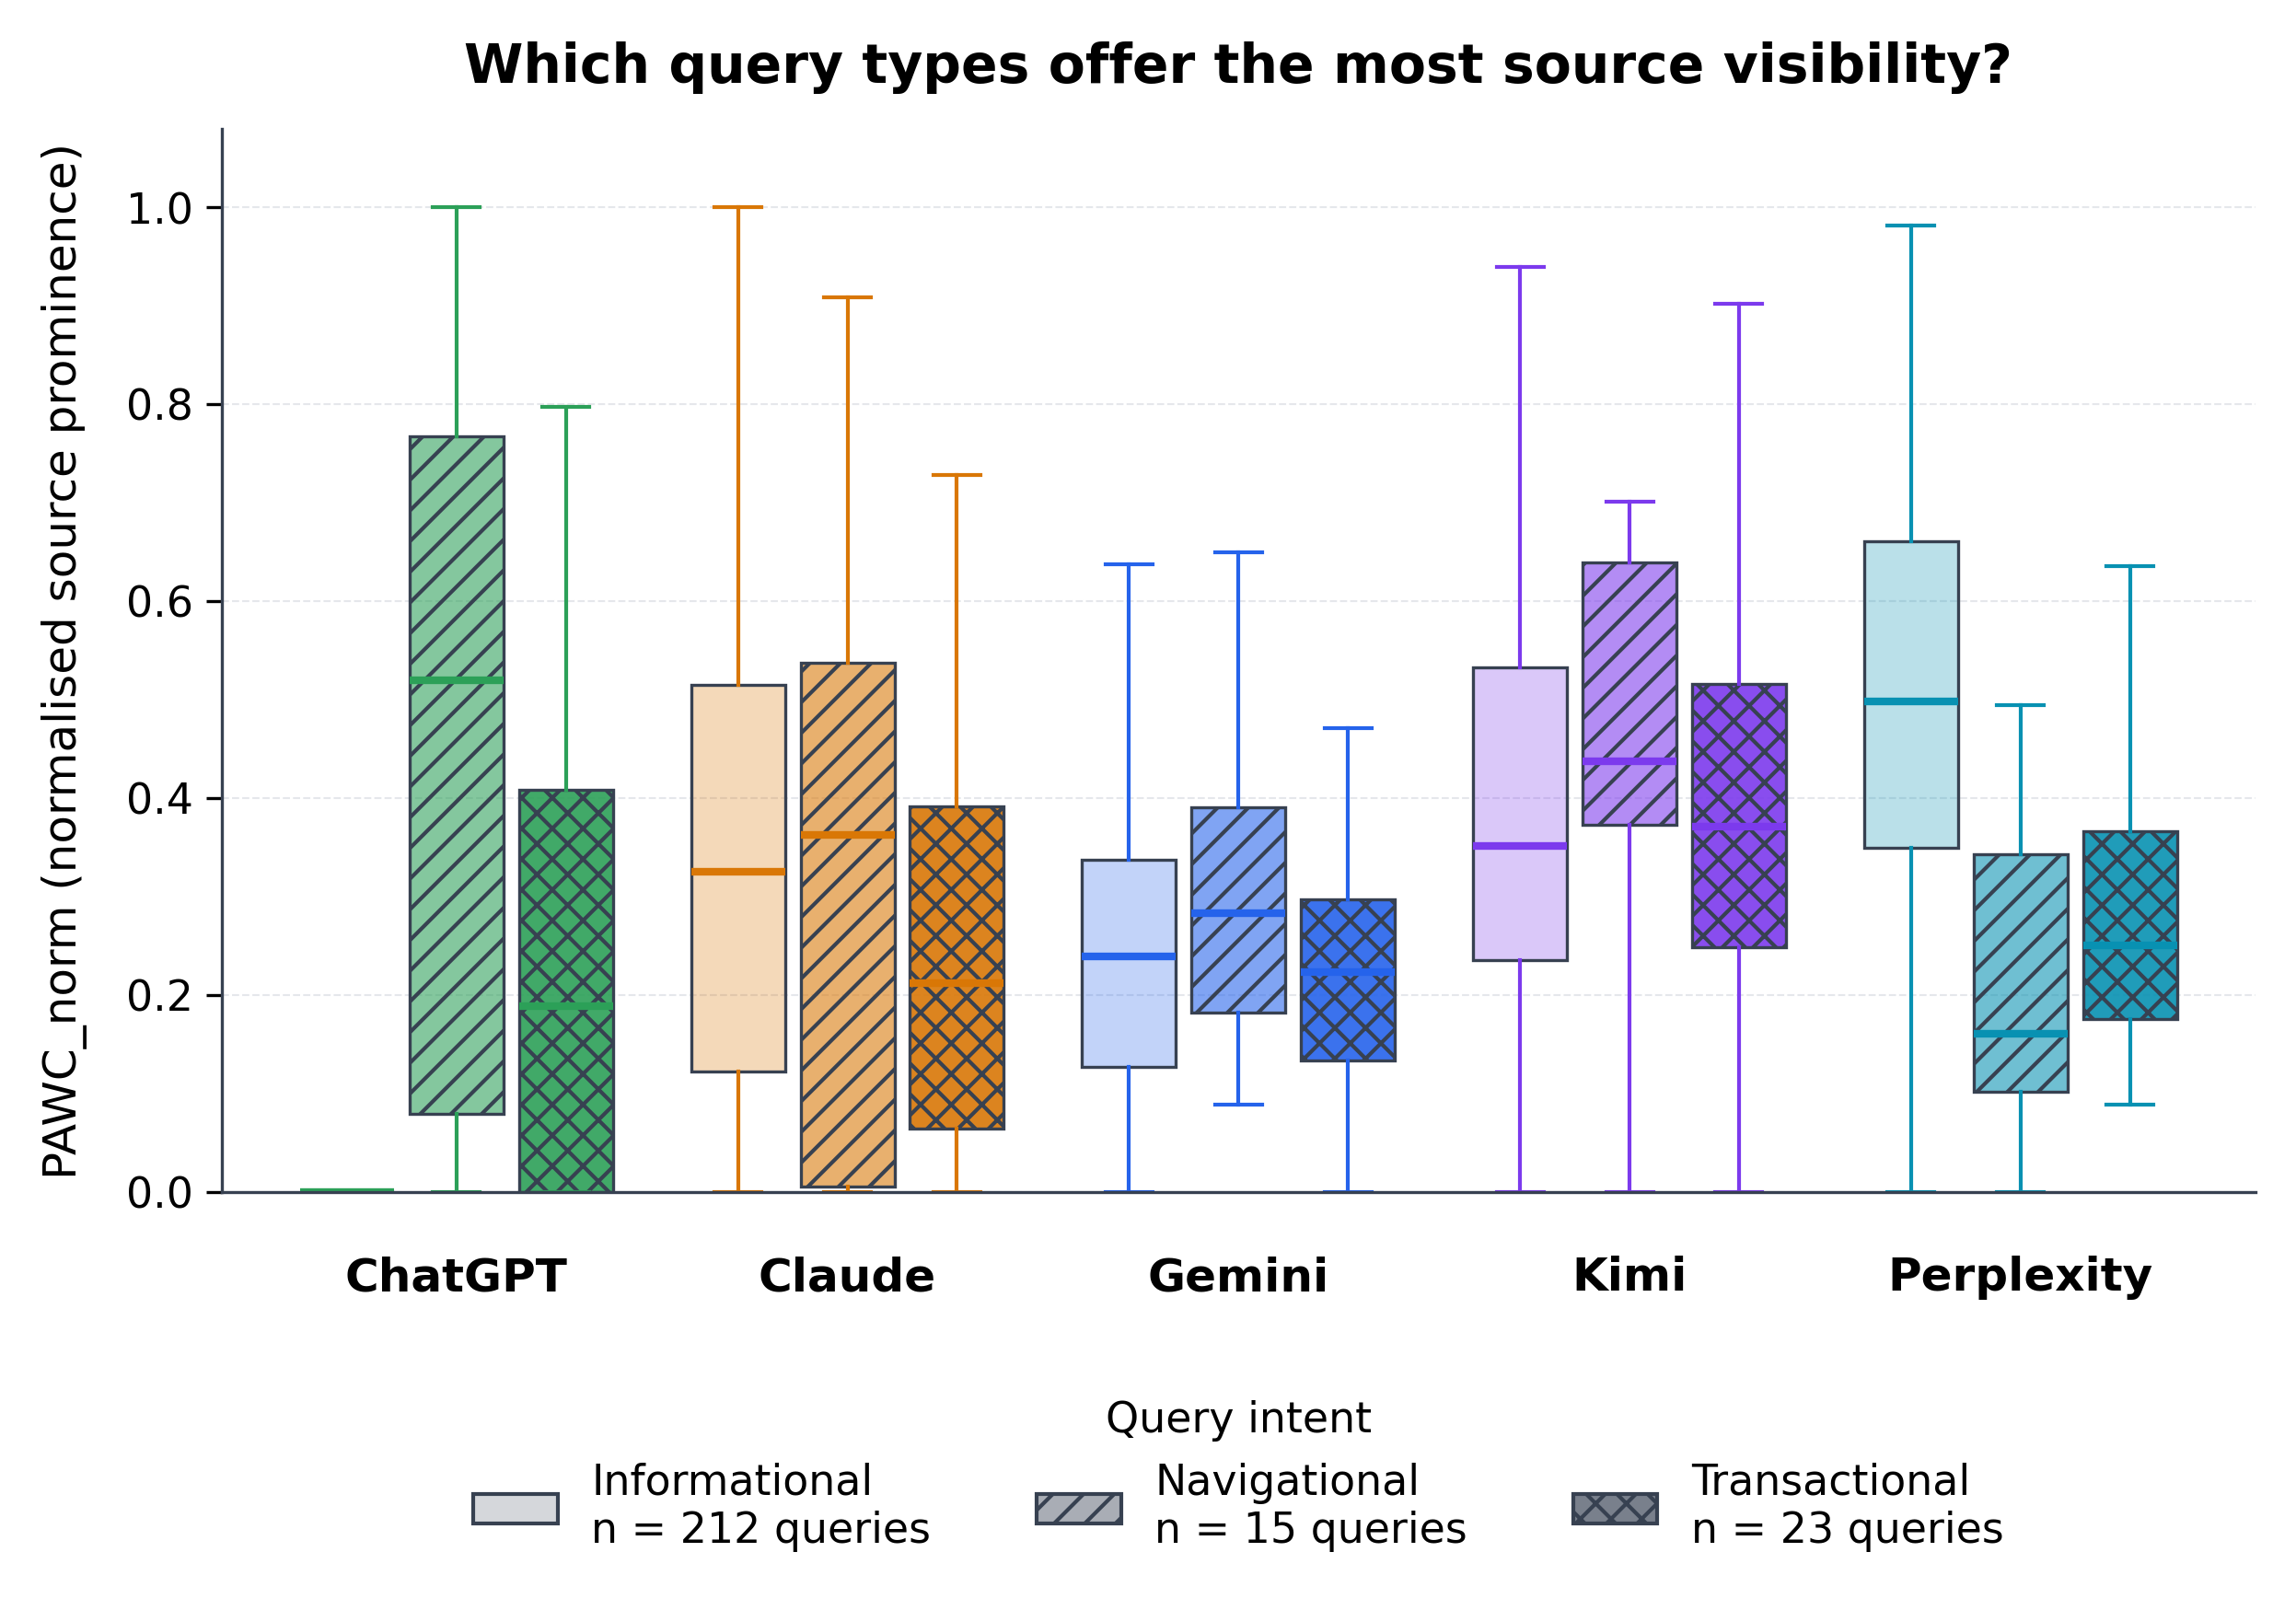

In [7]:
# Q5 · PAWC_norm by engine x query intent (cell-level pawc_norm_mean, NaN->0). Intent = shade + hatch; query n in legend.
d = ca.merge(qf, on="query_id").assign(p=lambda t: t.pawc_norm_mean.fillna(0))
intents = ["informational", "navigational", "transactional"]
nq = qf.intent.value_counts()                                                   # query counts per intent: 212 / 15 / 23
al    = {"informational": 0.28, "navigational": 0.58, "transactional": 0.90}    # fill shade (light -> dark)
hat   = {"informational": "",   "navigational": "///", "transactional": "xxx"}  # texture (greyscale-safe)
fig, ax = plt.subplots(figsize=(9.5, 5.0))
for i, e in enumerate(ENGINE_ORDER):
    for j, it in enumerate(intents):
        vals = d[(d.engine == e) & (d.intent == it)].p.values; pos = i + (j - 1) * 0.28
        bp = ax.boxplot(vals, positions=[pos], widths=0.24, patch_artist=True, showfliers=False)
        bp["boxes"][0].set(facecolor=mpl.colors.to_rgba(ENGINE_COLOURS[e], al[it]),
                           edgecolor="#374151", linewidth=0.8, hatch=hat[it])
        for m in bp["medians"]: m.set(color=ENGINE_COLOURS[e], linewidth=2)
        for wk in bp["whiskers"] + bp["caps"]: wk.set(color=ENGINE_COLOURS[e], linewidth=1)
    ax.text(i, -0.06, ENGINE_LABELS[e], transform=ax.get_xaxis_transform(),
            ha="center", va="top", fontsize=12, fontweight="semibold")
ax.set_xticks([]); ax.set_xlim(-0.6, 4.6)
ax.set_ylabel("PAWC_norm (normalised source prominence)"); ax.set_ylim(0, d.p.max() * 1.08)
ax.set_title("Which query types offer the most source visibility?", pad=12)
ax.legend(handles=[Patch(facecolor=mpl.colors.to_rgba(COLOUR_NEUTRAL, al[it]), edgecolor="#374151",
                         hatch=hat[it], label=f"{it.capitalize()}\nn = {int(nq[it])} queries") for it in intents],
          title="Query intent", loc="upper center", bbox_to_anchor=(0.5, -0.16), ncol=3, columnspacing=2.5)
apply_style(ax)
savefig(fig, "fig_rq1_q5_intent_boxplots")

**Key analysis.** Within each engine the three boxes split queries by what the user wants — information, a
specific site, or to do something — so you can see which query types carry the most source visibility. Only
informational queries are well-powered (212 of 250), and there the headline holds: **Perplexity is highest (median
0.50) and ChatGPT essentially zero**. Navigational queries look more prominent on four of five engines, but that
rests on just 15 queries, so do not build a plan on it. The safe, reliable opportunity sits in informational and
explainer content — target that, and treat the navigational signal as something to confirm with a bigger test.

## Appendix Figure A3 — per-run PAWC_norm distribution by engine

The main RQ1 figures compress each engine to a single mean. This appendix figure shows the **full per-run
distribution** of PAWC_norm (all 9,992 runs) as box plots, so the spread and skew behind those means is visible.
Two panels: **All runs** counts every run — a run that fetched no source scores 0 (`pawc_norm` NaN → 0); **Retrieved
runs** keeps only the runs that fetched at least one source (`n_sources_fetched_ok > 0`, i.e. where PAWC_norm is
defined), including the genuine zero-prominence retrievals. Reading the two together separates *how often* an engine
retrieves from *how prominent* it is once it does.

saved fig_rq1_appendix_a3_pawcnorm_boxplots -> figures/scaleup/


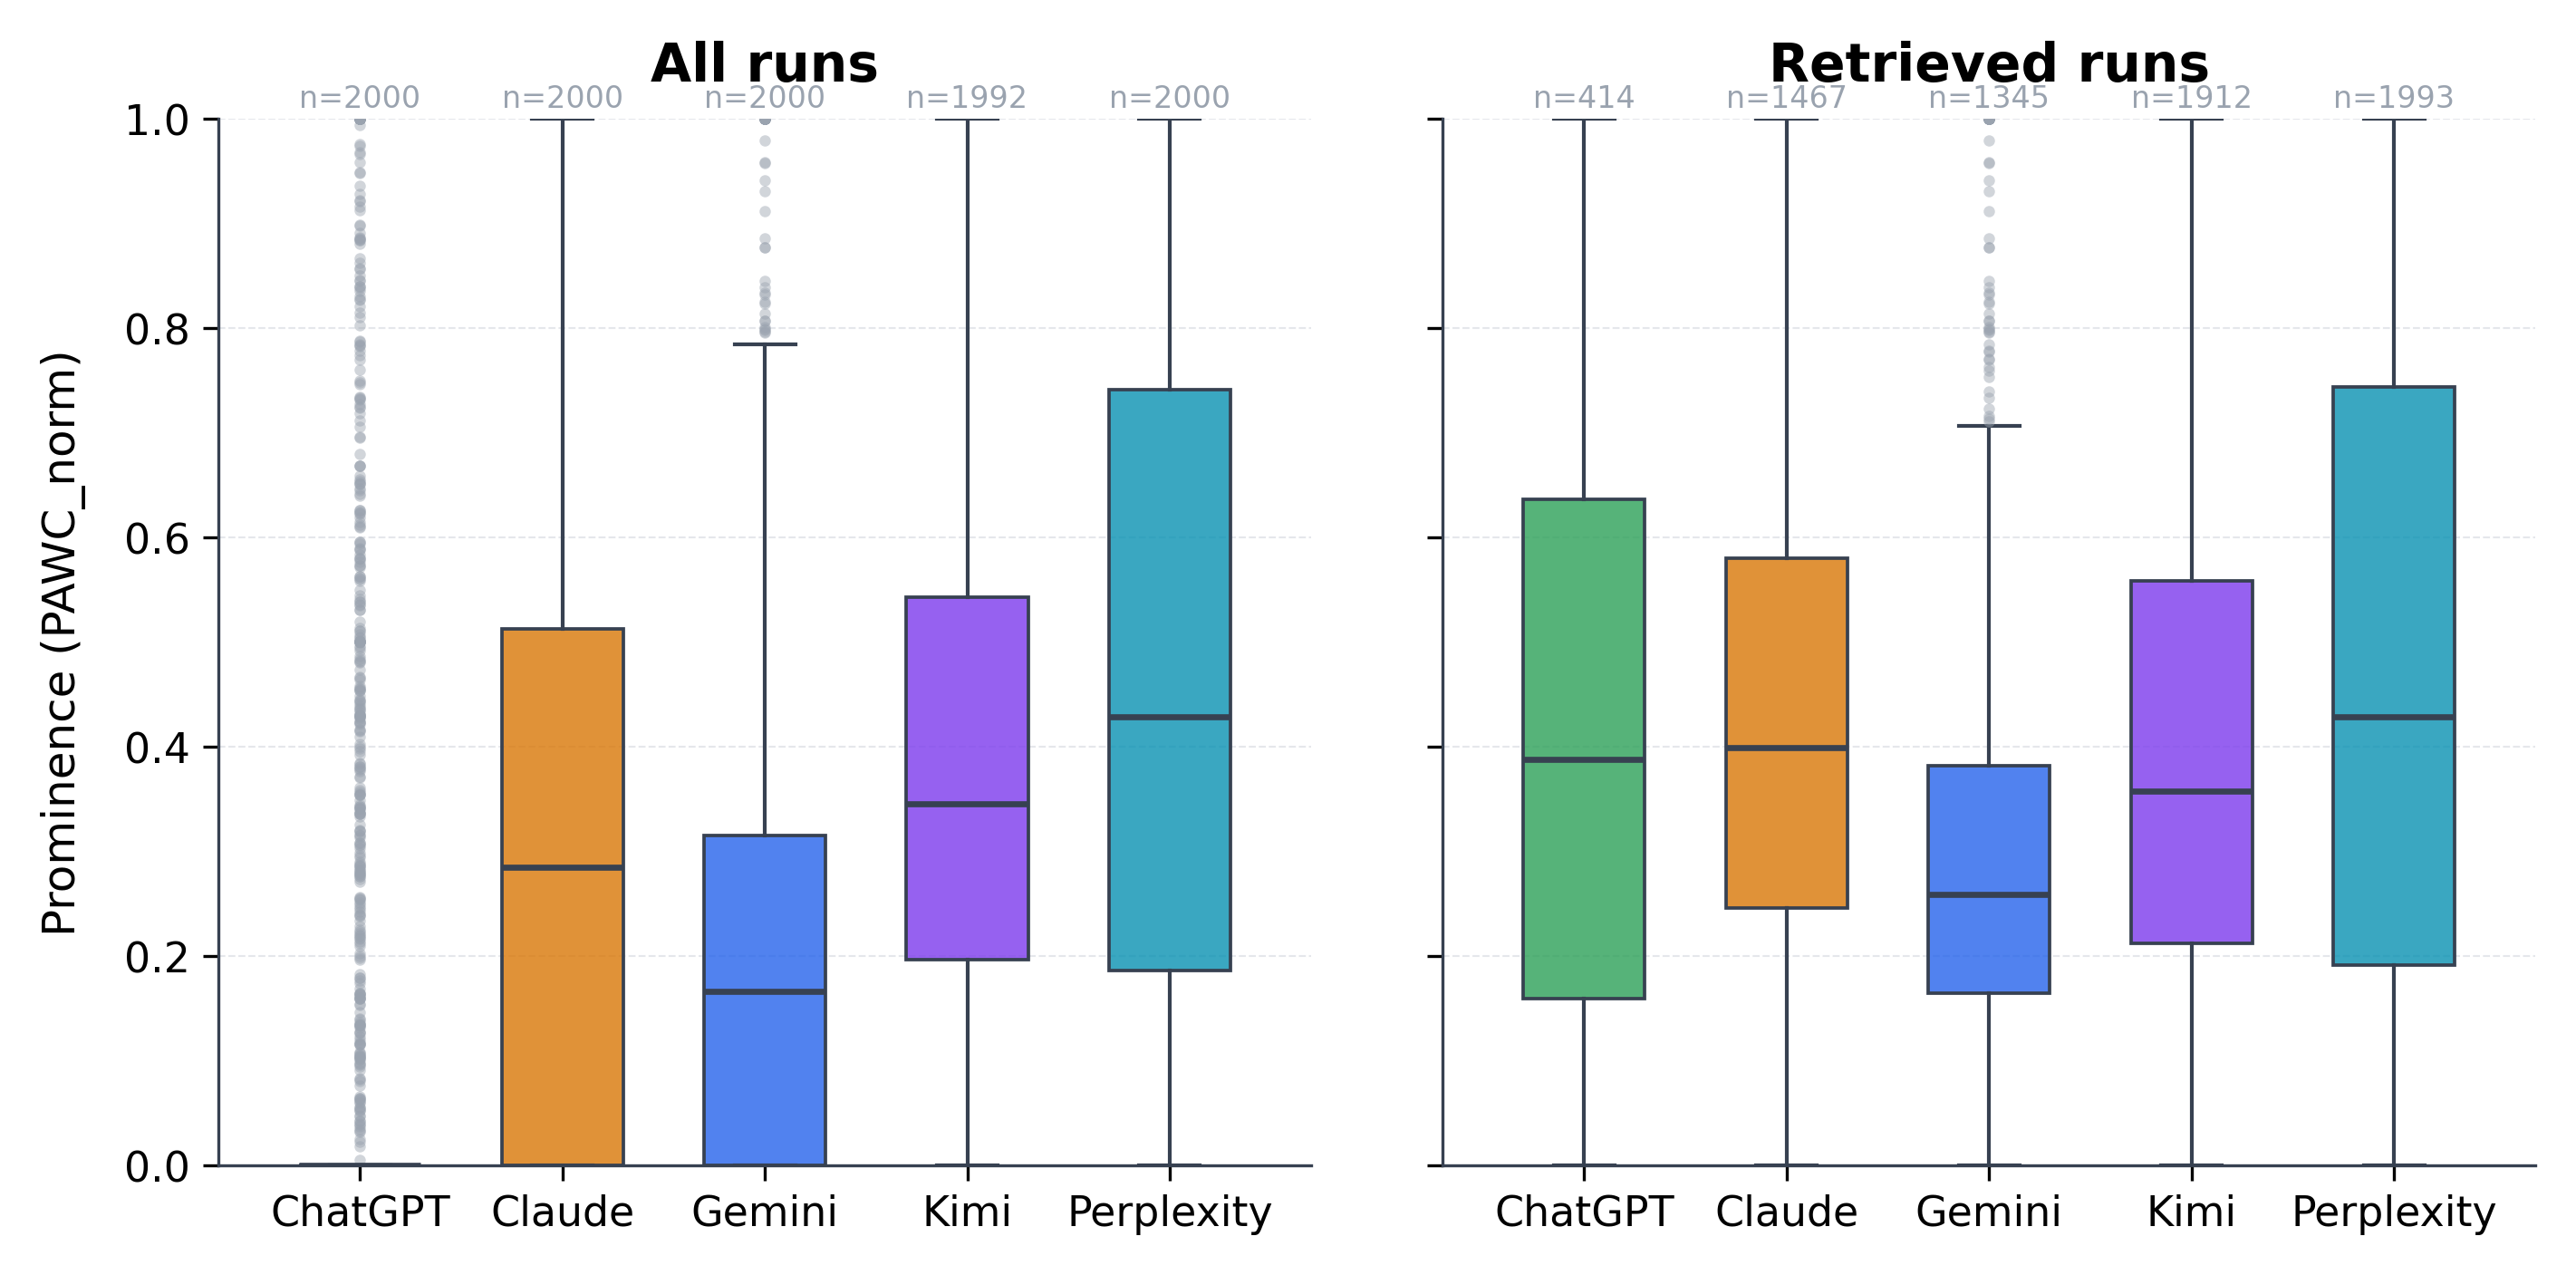

In [8]:
# A3 · Per-run PAWC_norm by engine — two panels (all runs, NaN->0 | retrieved runs, pawc_norm defined).
# Saved to figures/scaleup/ (not the rq/ subdir). Median = dark-grey line; outliers = small grey dots.
GREY_MEDIAN, GREY_FLIER = "#374151", "#9AA3AF"
all_runs = {e: f1.loc[f1.engine == e, "pawc_norm"].fillna(0).values for e in ENGINE_ORDER}     # every run
ret_runs = {e: f1.loc[f1.engine == e, "pawc_norm"].dropna().values for e in ENGINE_ORDER}      # fetched >=1 source
for e in ENGINE_ORDER:                                                                          # retrieved == fetched_ok>0
    assert len(ret_runs[e]) == int(((f1.engine == e) & (f1.n_sources_fetched_ok > 0)).sum())

def _panel(ax, data, title):
    pos = np.arange(len(ENGINE_ORDER))
    bp = ax.boxplot([data[e] for e in ENGINE_ORDER], positions=pos, widths=0.6, patch_artist=True,
                    showfliers=True, medianprops=dict(color=GREY_MEDIAN, linewidth=1.6),
                    whiskerprops=dict(color="#374151", linewidth=1.0),
                    capprops=dict(color="#374151", linewidth=1.0),
                    flierprops=dict(marker="o", markersize=3, markerfacecolor=GREY_FLIER,
                                    markeredgecolor="none", alpha=0.45))
    for patch, e in zip(bp["boxes"], ENGINE_ORDER):
        patch.set(facecolor=mpl.colors.to_rgba(ENGINE_COLOURS[e], 0.80), edgecolor="#374151", linewidth=0.9)
    ax.set_xticks(pos); ax.set_xticklabels([ENGINE_LABELS[e] for e in ENGINE_ORDER])
    ax.set_ylim(0, 1); ax.set_xlim(-0.7, len(ENGINE_ORDER) - 0.3); ax.set_title(title, pad=10)
    for i, e in enumerate(ENGINE_ORDER):
        ax.text(i, 1.005, f"n={len(data[e])}", ha="center", va="bottom", fontsize=8, color=GREY_FLIER)
    apply_style(ax)

fig, (axL, axR) = plt.subplots(1, 2, figsize=(11, 5), sharey=True)
_panel(axL, all_runs, "All runs"); _panel(axR, ret_runs, "Retrieved runs")
axL.set_ylabel("Prominence (PAWC_norm)"); fig.subplots_adjust(wspace=0.12)
for ext in ("png", "pdf"):
    fig.savefig(f"../../figures/scaleup/fig_rq1_appendix_a3_pawcnorm_boxplots.{ext}")
print("saved fig_rq1_appendix_a3_pawcnorm_boxplots -> figures/scaleup/")

**Key analysis.** Splitting each engine into its full per-run spread shows the means hide two very different stories.
In **All runs**, ChatGPT's box collapses onto zero — its median, lower and upper quartiles are all 0, because it
surfaces no source on the majority of runs — while Perplexity's box sits highest and widest. But condition on the
engine actually retrieving (**Retrieved runs**) and ChatGPT jumps to a median around 0.39, in line with Claude and
Kimi: when ChatGPT does fetch a source it is prominent, it just rarely fetches (n falls from 2,000 to 414). Gemini is
the outlier that stays low in *both* panels (retrieved median ≈ 0.26) — its weakness is what it surfaces, not how
often it retrieves. Perplexity barely moves between panels (median 0.43 → 0.43) because it retrieves on almost every
run, so its unconditional and retrieved distributions are essentially the same.